**LOAD DATASET**

Eksperimen ini bertujuan untuk membangun model foreasting (peramalan) suhu ruangan 30 menit kedepan dengan menggunakan dataset RICO Fase 5. Karena sifat suhu yang dipengaruhi oleh cuaca di masa lalu (delay), eksperimen ini menggunakan pendekatan Time-Series Forecasting dengan teknik pembuatan Lag Features. Data dibersihkan menggunakan interpolasi waktu untuk menjaga kesinambungan urutan data. Enam algoritma dievaluasi secara kompetitif melawan Baseline Naive (tebakan statis), di mana 3 model terbaik dioptimasi lebih lanjut menggunakan Time-Series Cross Validation. Hasil akhirnya disimulasikan sebagai pengambil keputusan cerdas pada sistem HVAC untuk menghemat energi gedung."

paper dataset: https://www.sciencedirect.com/science/article/pii/S2352340925004081

dataset : https://zenodo.org/records/14871584



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


menyiapkan environtment dan memuat data HDF5 menggunakan pandas

(pd.read_hdf jauh lebih tangguh dan minim error)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, ParameterGrid
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
import joblib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
path = "/content/drive/MyDrive/ujikom/DATA/RICO_Acquisition_5_05-2024.hdf"

try:
    # Membaca file HDF5 secara otomatis dengan Pandas
    df = pd.read_hdf(path)
except Exception as e:
    print(f"Gagal memuat data: {e}")
    # Fallback jika butuh key spesifik
    df = pd.read_hdf(path, key='data')

# Pastikan waktu menjadi index
if 'Time' in df.columns:
    df['Time'] = pd.to_datetime(df['Time'])
    df = df.sort_values('Time').set_index('Time')

print("Dataset shape:", df.shape)

Dataset shape: (14400, 82)


**EDA**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14400 entries, 2024-05-08 07:01:00+00:00 to 2024-05-18 07:00:00+00:00
Freq: min
Data columns (total 82 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Acquisition Phase        14400 non-null  int64  
 1   Scheduler Step           14400 non-null  int64  
 2   Flag                     14400 non-null  int64  
 3   pid.EC3.setpoint         14400 non-null  float64
 4   pid.SB43.setpoint        14400 non-null  float64
 5   pid.SB46.setpoint        14400 non-null  float64
 6   pid.SB47.setpoint        14400 non-null  float64
 7   B.ASTRHT2.H              14400 non-null  float64
 8   B.ASTRHT2.S              14400 non-null  float64
 9   B.ASTRHT2.T              14400 non-null  float64
 10  B.RTD1                   14400 non-null  float64
 11  B.RTD2                   14400 non-null  float64
 12  B.RTD3                   14400 non-null  float64
 13  B.RTD6             

In [5]:
df.head(15)

Index,Acquisition Phase,Scheduler Step,Flag,pid.EC3.setpoint,pid.SB43.setpoint,pid.SB46.setpoint,pid.SB47.setpoint,B.ASTRHT2.H,B.ASTRHT2.S,B.ASTRHT2.T,...,pid.EC3.enabled,pid.SB43.enabled,pid.SB46.enabled,pid.SB47.enabled,WS1_Solar_radiation,WS1_Temperature,BF.SIM1,O.SIM1,O.SIM2,O.SIM3
_time,,,,,,,,,,,,,,,,,,,,,
2024-05-08 07:01:00+00:00,5,0,1,30.0,0.0,16.2,53.3,16.8,1.0,25.2,...,1.0,0.0,1.0,1.0,113.0,8.7,13.7,805.7,47.2,43.3
2024-05-08 07:02:00+00:00,5,0,1,10.0,0.0,6.0,20.0,16.0,1.2,26.1,...,0.3,0.0,0.3,0.3,113.7,8.6,13.8,806.5,47.7,44.0
2024-05-08 07:03:00+00:00,5,0,1,0.0,0.0,0.0,0.0,16.0,1.3,26.4,...,0.0,0.0,0.0,0.0,115.5,8.6,13.9,809.0,48.3,44.8
2024-05-08 07:04:00+00:00,5,0,1,0.0,0.0,0.0,0.0,15.8,1.2,26.5,...,0.0,0.0,0.0,0.0,116.0,8.6,13.9,811.3,49.0,44.8
2024-05-08 07:05:00+00:00,5,0,1,0.0,0.0,0.0,0.0,15.0,1.2,26.9,...,0.0,0.0,0.0,0.0,117.0,8.5,14.0,800.8,49.0,44.8
2024-05-08 07:06:00+00:00,5,0,1,0.0,0.0,0.0,0.0,15.0,1.2,27.4,...,0.0,0.0,0.0,0.0,116.2,8.5,14.0,814.8,49.0,45.0
2024-05-08 07:07:00+00:00,5,0,1,0.0,0.0,0.0,0.0,15.0,1.3,27.5,...,0.0,0.0,0.0,0.0,114.7,8.5,13.8,813.3,49.0,44.7
2024-05-08 07:08:00+00:00,5,0,1,0.0,0.0,0.0,0.0,15.0,1.2,27.6,...,0.0,0.0,0.0,0.0,113.7,8.5,13.8,814.8,49.2,44.8
2024-05-08 07:09:00+00:00,5,0,1,0.0,0.0,0.0,0.0,15.0,1.2,27.8,...,0.0,0.0,0.0,0.0,115.2,8.5,14.1,807.7,50.3,45.7


In [6]:
df.shape

(14400, 82)

duplicate rows: 0
Missing values: 0

=== STATISTIK DESKRIPTIF ===


Index,B.RTD6,WS1_Solar_radiation,WS1_Temperature,pid.SB47.setpoint,JP41_volumeFlow
count,14400.000000,14400.000000,14400.000000,14400.000000,14400.0
mean,22.252660,195.019569,14.041972,30.338424,0.0
std,4.349258,223.739273,5.688944,22.651644,0.0
min,14.500000,0.000000,3.700000,0.000000,0.0
25%,19.200000,5.000000,9.300000,20.000000,0.0
50%,21.400000,86.000000,12.800000,40.000000,0.0
75%,24.900000,350.800000,18.500000,60.000000,0.0
max,35.200000,841.800000,27.700000,60.000000,0.0


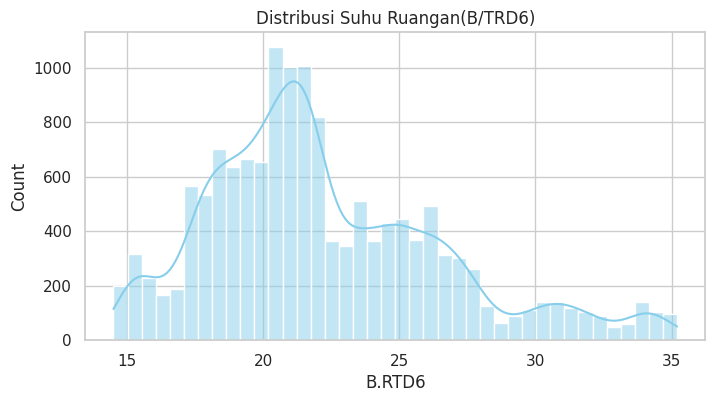

In [7]:
print("duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

selected_cols = [
    'B.RTD6','WS1_Solar_radiation',
    'WS1_Temperature','pid.SB47.setpoint',
    'JP41_volumeFlow'
]
selected_cols = [c for c in selected_cols if c in df.columns]

print("\n=== STATISTIK DESKRIPTIF ===")
display(df[selected_cols].describe())

sns.set_theme(style="whitegrid")

#Distribusi Suhu Ruangan
plt.figure(figsize=(8,4))
sns.histplot(df['B.RTD6'], bins=40,kde=True, color='skyblue')
plt.title("Distribusi Suhu Ruangan(B/TRD6)")
plt.show()

Ini membuktikan bahwa selama berhari-hari, suhu normal gedung tersebut sering kali dijaga di zona sejuk/nyaman (sekitar 21°C). Ekor panjang ke kanan (yang disebut right-skewed) menunjukkan bahwa ada momen-momen spesifik di mana ruangan dibuat sangat panas (hingga 35°C). Hal ini masuk akal karena dataset RICO adalah data eksperimen gedung, di mana pemanas kadang sengaja dinyalakan maksimal untuk menguji respons sistem. Model AI Anda belajar bahwa suhu 35°C itu jarang, tapi bisa terjadi.

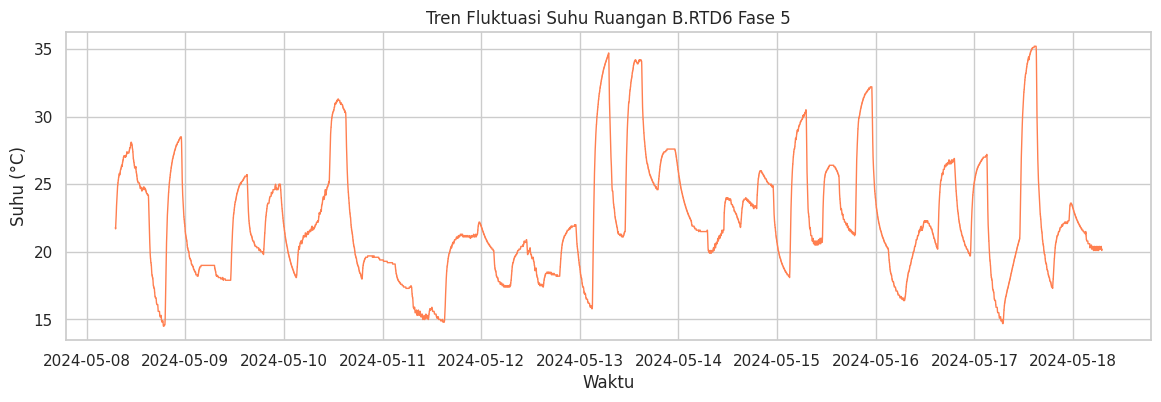

In [8]:
#Tren Waktu
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['B.RTD6'], color='coral', linewidth=1)
plt.title("Tren Fluktuasi Suhu Ruangan B.RTD6 Fase 5")
plt.xlabel("Waktu")
plt.ylabel("Suhu (°C)")
plt.show()

Ini adalah bukti visual dari sifat Time-Series (Deret Waktu). suhu ruangan tdak pernah berubah secara instan dari 15°C langsung ke 30°C dalam 1 detik. ada tahapan. Grafik lengkung ini membuktikan bahwa harus ada lag feature ( fitur ingatan masa lalu ) , karena suhu memiliki momentum , dan sistem wajib melihat pergerakan historis untuk menentukan masa depan

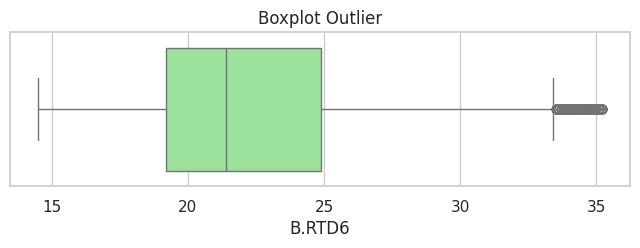

In [9]:
# Boxplot Outlier
plt.figure(figsize=(8,2))
sns.boxplot(x=df['B.RTD6'], color='lightgreen')
plt.title("Boxplot Outlier")
plt.show()

walaupun itu ada outlier , tapi langkahnya nanti tidak akan dihapus , karena: outlier ada 2 , outlier statistik dan outlier error logika

1. outlier disini termasuk outlier statistik , Titik-titik hitam di angka 33°C - 35°C pada gambar Boxplot itu adalah Outlier Statistik. Rumus matematika (Interquartile Range/IQR) menganggap angka 35°C itu "aneh" karena mayoritas suhu harian cuma berkisar di 21°C. secara realita juga , suhu 35 itu mungkin terjadi ( misal ac mati disiang hari atau saat eksperimen pemanas gedung sedang dimaksimalkan ) jika data 35 derajat dihapus maka , model akan buta terhadap suhu ekstrem yang mungkin terjadi

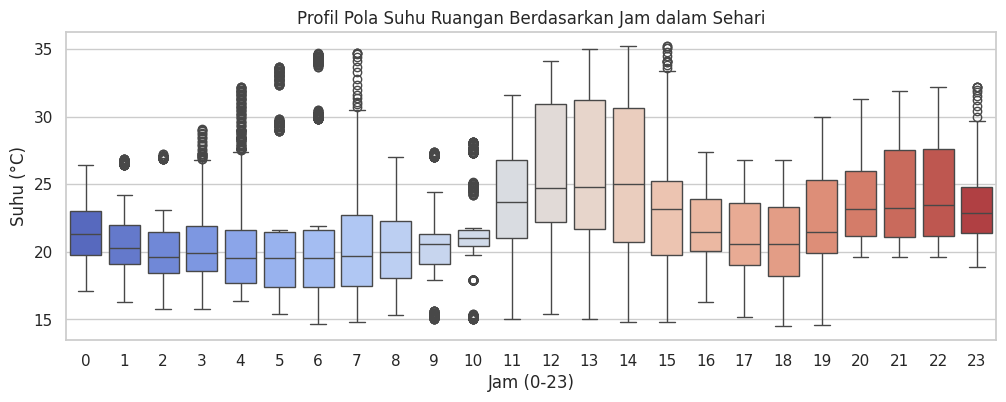

In [10]:
#Profil Suhu Berdasarkan Jam (Domain Knowledge HVAC)
df_eda = df.copy()
df_eda['Hour'] = df_eda.index.hour
plt.figure(figsize=(12,4))
sns.boxplot(x='Hour', y='B.RTD6', data=df_eda, palette='coolwarm')
plt.title("Profil Pola Suhu Ruangan Berdasarkan Jam dalam Sehari")
plt.xlabel("Jam (0-23)")
plt.ylabel("Suhu (°C)")
plt.show()

Grafik ini membuktikan bahwa waktu sangat memengaruhi suhu. Di siang hari (jam 11-15), panas matahari meningkat ,  membuat suhu ruangan naik drastis. Di malam hari, suhu cenderung stabil. Ini membenarkan kenapa suhu luar ruangan dan radiasi matahari wajib dimasukkan sebagai fitur (input) untuk AI.

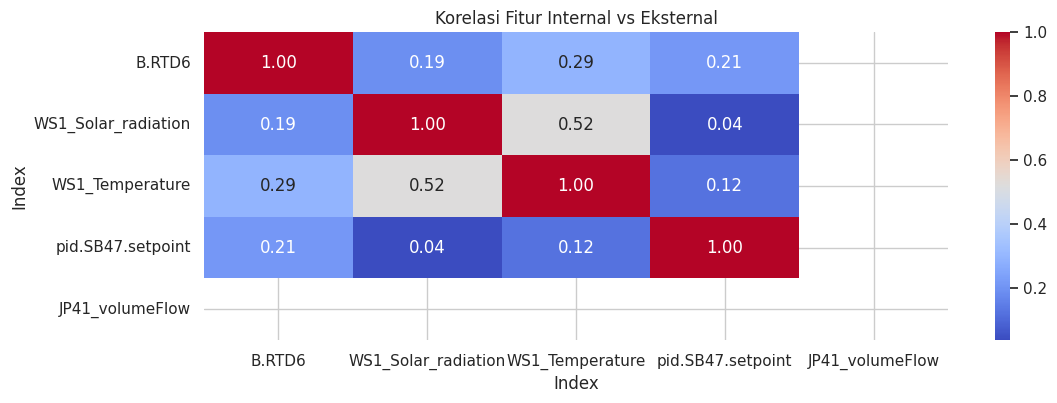

In [11]:
#korelasi fitur internal vs eksternal
plt.figure(figsize=(12,4))
sns.heatmap(df[selected_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasi Fitur Internal vs Eksternal")
plt.show()

Angka 0.29 menunjukkan bahwa cuaca di luar gedung punya pengaruh yang cukup lumayan terhadap suhu di dalam gedung (meskipun tidak absolut, karena ada insulasi tembok).

  - ada juga yang kosong , pompa ini mati (JP41_volumeFlow)

In [12]:
# 1. Filter data khusus saat radiasi matahari bernilai 0
df_matahari_nol = df[df['WS1_Solar_radiation'] == 0]

# 2. Ambil informasi 'Jam' dari index waktu, lalu hitung frekuensinya
jam_kejadian = df_matahari_nol.index.hour.value_counts().sort_index()

print("Distribusi kejadian Radiasi Matahari = 0 berdasarkan Jam:")
print("-" * 50)
for jam, jumlah in jam_kejadian.items():
    print(f"Jam {jam:02d}:00  -->  Terjadi {jumlah} kali")

print("-" * 50)
print("Daftar unik jamnya:", sorted(df_matahari_nol.index.hour.unique()))

Distribusi kejadian Radiasi Matahari = 0 berdasarkan Jam:
--------------------------------------------------
Jam 00:00  -->  Terjadi 92 kali
Jam 01:00  -->  Terjadi 101 kali
Jam 20:00  -->  Terjadi 23 kali
Jam 21:00  -->  Terjadi 44 kali
Jam 22:00  -->  Terjadi 54 kali
Jam 23:00  -->  Terjadi 47 kali
--------------------------------------------------
Daftar unik jamnya: [0, 1, 20, 21, 22, 23]


HASIL EDA

1. - Dataset memiliki 14.400 baris dan 82 kolom
   - data direkam per 1 menit
   - tidak ada duplicate row
   - tidak ada missing value

Bisa dapat disimpulkan bahwa dataset sudah bersih dan stabil

2. Distribusi Suhu (B.RTD6)
    
    - Mean = 22.25°C

    - Median = 21.4°C

    - Min = 14.5°C

    - Max = 35.2°C

    - Std = 4.35°C

  Distribusi sedikit right-skewed (karena ada puncak suhu tinggi saat eksperimen heating), tidak ada nilai ekstream tidak masuk akal , dan Rentang suhu realistis untuk eksperimen HVAC

  3. Tren Waktu
  Dari grafik time-series:

    - Terlihat fluktuasi harian

    - Ada kenaikan tajam saat eksperimen pemanasan

    - Ada penurunan saat pendinginan

Kesimpulan:

Data memiliki pola dinamis dan transitory regime, cocok untuk forecasting multivariate.

4. Suhu Ruangan (Target B.RTD6) Logis dan Natural: * Suhu berfluktuasi antara 14.5 °C hingga 35.2 °C. Ini adalah rentang suhu yang sangat wajar untuk sebuah ruangan, membuktikan tidak ada sensor suhu yang rusak (seperti tiba-tiba mencatat suhu 0 °C atau 100 °C).

    - Grafik Tren Waktu dan Profil Jam membuktikan adanya siklus harian (diurnal cycle) yang kuat: suhu turun di malam/pagi hari dan memuncak di siang/sore hari.

5. kolom JP41_volumeFlow memiliki nilai min, max, mean, dan std semuanya 0.0. Ini berarti pompa air panas tersebut mati total selama Fase 5 ini. Hal ini juga tervalidasi di grafik Heatmap Anda di mana baris/kolom JP41_volumeFlow kosong (tidak ada korelasi) karena tidak ada variasi data sama sekali.

6. di posisi seperti ini angka 0 disini bukan berarti missing value tapi kalau kita lihat dari data descriptive hasil dari radiasi matahaari menunjukan ada angka min 0 , karena matahari tenggelam di malam hari dan dibuktikan juga di pengecekan terakhir sehingga dapat digunakan sebagai bukti empiris , jadi sensor cahaya mencatata angka 0 , dan ini normal , posisi suhu di ruangan B.RTD6 juga stabil , suhu paling rendah ada di angka 14.5 dan tidak ada 0



**CLEANING DAN INTERPOLASI**

In [13]:
df = df.drop_duplicates()

# 1. Hapus kolom statis (JP41_volumeFlow akan terhapus di sini)
static_cols = df.nunique()[df.nunique()==1].index
df = df.drop(columns=static_cols)

# 2. PENGAMAN: Update selected_cols agar hanya memanggil yang MASIH ADA di df
selected_cols = [c for c in selected_cols if c in df.columns]

# 3. Sekarang baru aman difilter
df = df[selected_cols]

# 4. Interpolasi & Filter Suhu (Lanjutkan seperti biasa)
df = df.interpolate(method='time', limit_direction='both')
df = df[(df['B.RTD6'] >= 5) & (df['B.RTD6'] <= 45)]

print("Data berhasil dibersihkan! Sisa kolom:", df.columns.tolist())

Data berhasil dibersihkan! Sisa kolom: ['B.RTD6', 'WS1_Solar_radiation', 'WS1_Temperature', 'pid.SB47.setpoint']


In [14]:
# ALASAN: Membuat fitur "masa lalu" (lag) agar model bisa memahami jeda waktu (delay)
# dari panas matahari menuju kenaikan suhu ruangan. Target diset 30 menit ke depan.

lags = [1, 5, 10, 15, 30]
for lag in lags:
    df[f'lag_temp_{lag}'] = df['B.RTD6'].shift(lag)

df['target'] = df['B.RTD6'].shift(-30)

# Menghapus NaN yang muncul di awal dan akhir akibat proses pergeseran waktu (shift)
df = df.dropna()

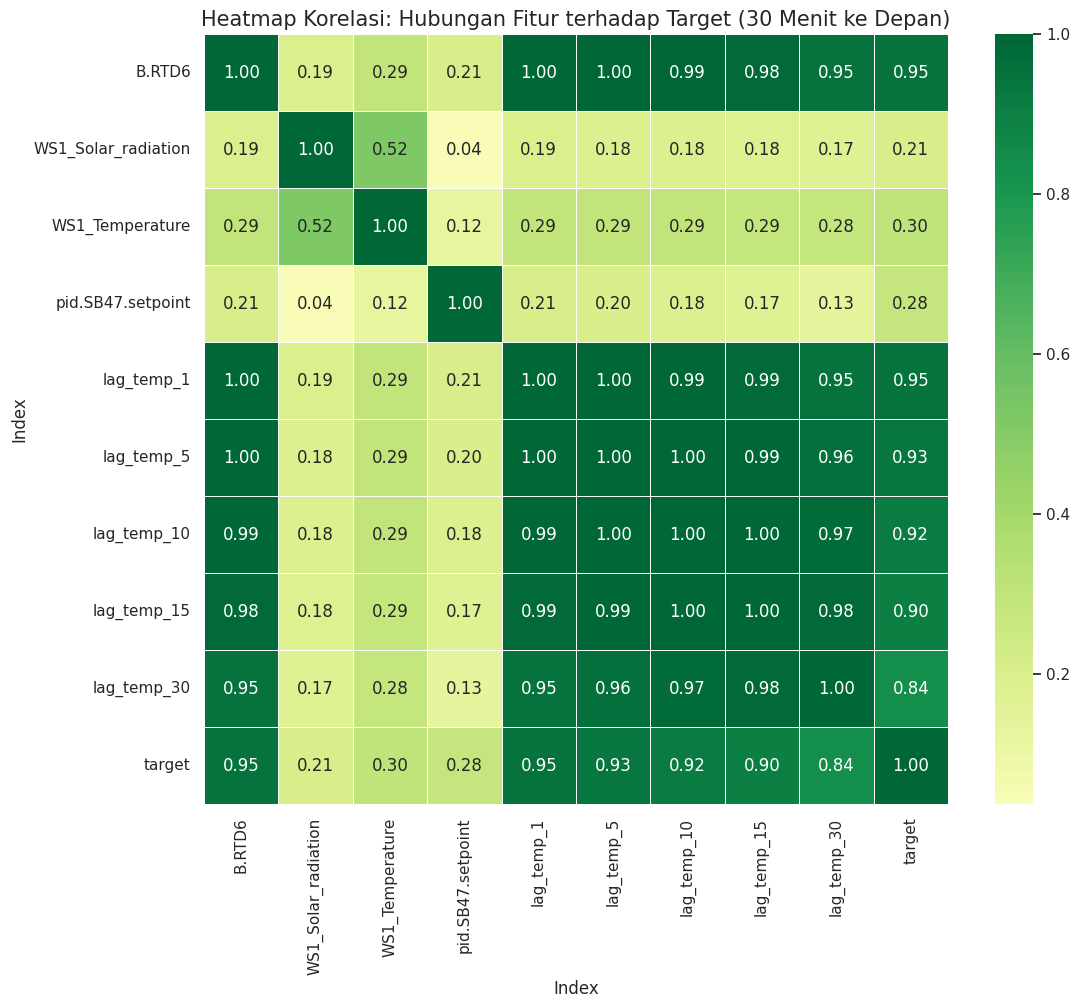


=== URUTAN FITUR PALING BERPENGARUH TERHADAP TARGET ===
Index
target                 1.000000
B.RTD6                 0.948056
lag_temp_1             0.945102
lag_temp_5             0.932789
lag_temp_10            0.916362
lag_temp_15            0.898859
lag_temp_30            0.840905
WS1_Temperature        0.299956
pid.SB47.setpoint      0.277475
WS1_Solar_radiation    0.211859
Name: target, dtype: float64


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Menghitung matriks korelasi
corr_matrix = df.corr()

# 2. Mengatur ukuran gambar
plt.figure(figsize=(12, 10))

# 3. Membuat Heatmap
# cmap='RdYlGn' memberikan warna Hijau untuk korelasi positif dan Merah untuk negatif
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)

plt.title('Heatmap Korelasi: Hubungan Fitur terhadap Target (30 Menit ke Depan)', fontsize=15)
plt.show()

# 4. Menampilkan urutan fitur yang paling berpengaruh terhadap Target
print("\n=== URUTAN FITUR PALING BERPENGARUH TERHADAP TARGET ===")
print(corr_matrix['target'].sort_values(ascending=False))

In [16]:
# ALASAN: Data waktu TIDAK BOLEH diacak (no shuffle). 80% data awal untuk belajar,
# 20% data akhir untuk ujian.

features = [c for c in df.columns if c != 'target']
split = int(len(df) * 0.8)

train = df.iloc[:split]
test  = df.iloc[split:]

X_train, y_train = train[features], train['target']
X_test,  y_test  = test[features],  test['target']

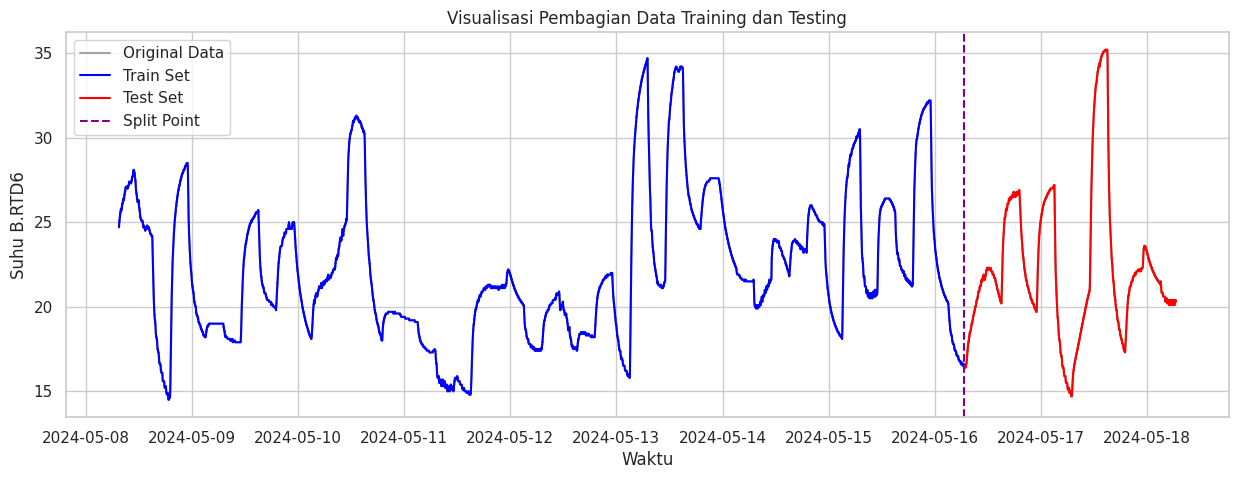

In [17]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['B.RTD6'], label='Original Data', color='gray', alpha=0.7)
plt.plot(train.index, train['B.RTD6'], label='Train Set', color='blue')
plt.plot(test.index, test['B.RTD6'], label='Test Set', color='red')
plt.axvline(x=train.index[-1], color='purple', linestyle='--', label='Split Point')
plt.title('Visualisasi Pembagian Data Training dan Testing')
plt.xlabel('Waktu')
plt.ylabel('Suhu B.RTD6')
plt.legend()
plt.show()

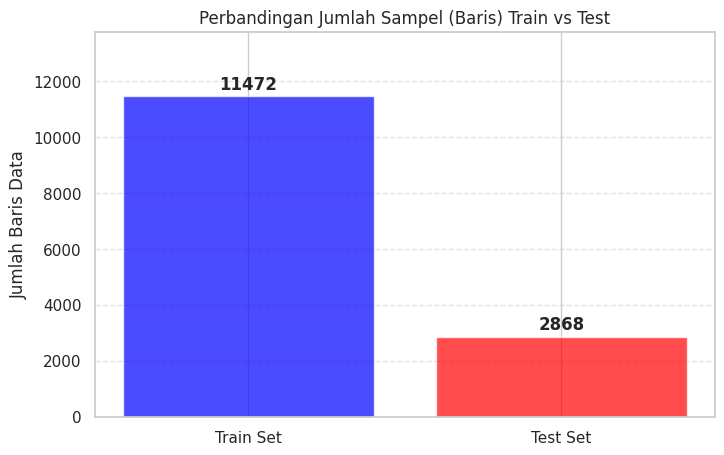

Total Data Training: 11472 baris
Total Data Testing: 2868 baris


In [18]:
import matplotlib.pyplot as plt

# Menghitung jumlah baris
train_count = len(X_train)
test_count = len(X_test)

# Visualisasi Bar Chart
plt.figure(figsize=(8, 5))
labels = ['Train Set', 'Test Set']
counts = [train_count, test_count]
colors = ['blue', 'red']

bars = plt.bar(labels, counts, color=colors, alpha=0.7)

# Menambahkan label angka di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, f'{int(yval)}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Perbandingan Jumlah Sampel (Baris) Train vs Test')
plt.ylabel('Jumlah Baris Data')
plt.ylim(0, max(counts) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print(f"Total Data Training: {train_count} baris")
print(f"Total Data Testing: {test_count} baris")

In [19]:
epsilon = 1e-6
baseline_pred = test['B.RTD6'] # Tebakan: Suhu saat ini

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mape = np.mean(np.abs((y_test - baseline_pred)/(y_test+epsilon)))*100
baseline_acc = 100 - baseline_mape

print(f" Baseline MAE: {baseline_mae:.4f} °C")
print(f" Baseline Accuracy: {baseline_acc:.2f}%")

 Baseline MAE: 0.9286 °C
 Baseline Accuracy: 95.88%


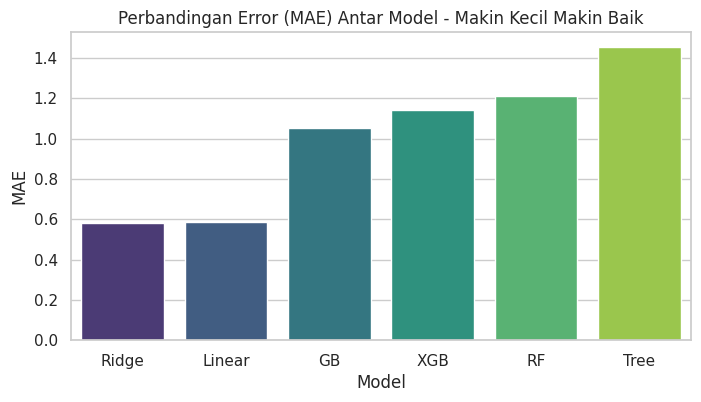

,Model,MAE,RMSE,Forecast_Accuracy
1,Ridge,0.580241,1.149330,97.450536
0,Linear,0.588668,1.139528,97.402936
4,GB,1.053597,1.688406,95.501332
5,XGB,1.141704,1.774966,95.194146
3,RF,1.213786,1.936551,94.794890
2,Tree,1.454916,2.266867,93.761729


In [20]:
models = {
    'Linear': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge())]),
    'Tree': DecisionTreeRegressor(random_state=42),
    'RF': RandomForestRegressor(random_state=42, n_jobs=-1),
    'GB': GradientBoostingRegressor(random_state=42),
    'XGB': XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = np.mean(np.abs((y_test - pred)/(y_test+epsilon)))*100
    acc = 100 - mape

    results.append([name, mae, rmse, acc])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "Forecast_Accuracy"])
results_df = results_df.sort_values("MAE")

# Visualisasi Peringkat Model
plt.figure(figsize=(8,4))
sns.barplot(data=results_df, x="Model", y="MAE", palette="viridis")
plt.title("Perbandingan Error (MAE) Antar Model - Makin Kecil Makin Baik")
plt.show()

display(results_df)



In [21]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, ParameterGrid
import numpy as np
from sklearn.metrics import mean_absolute_error

# ==============================================================================
# 🔹 8. HYPERPARAMETER TUNING (TOP 4)
# ==============================================================================
# ALASAN: Menghemat waktu komputasi dengan memeras potensi 4 model terbaik.
# Digunakan TimeSeriesSplit agar proses validasi tidak membocorkan data masa depan.

top4 = results_df["Model"].values[:4]
print("\nTop 4 Models untuk di-Tuning:", top4)

param_grid = {
    'RF': {'n_estimators': [100, 200], 'max_depth': [10, 20, None]},
    'GB': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'XGB': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'Ridge': {'model__alpha': [0.1, 1, 10]}
}

tscv = TimeSeriesSplit(n_splits=3)
best_model = None
best_score = np.inf
best_name = ""

for name in top4:
    model = models[name]
    grid = param_grid.get(name)

    if grid:
        # LOGIKA AMAN: Mencegah error jika kombinasi parameter (seperti Ridge) terlalu sedikit
        max_kombinasi = len(ParameterGrid(grid))
        n_iter_aman = min(5, max_kombinasi)

        search = RandomizedSearchCV(
            model, grid, n_iter=n_iter_aman,
            scoring='neg_mean_absolute_error',
            cv=tscv, n_jobs=-1, random_state=42
        )
        search.fit(X_train, y_train)
        model_terbaik_sementara = search.best_estimator_
        print(f"[{name}] Selesai Tuning. Parameter Terbaik: {search.best_params_}")
    else:
        # Bagian ini sangat jenius! Ini akan otomatis menangani model 'Linear'
        # yang memang tidak punya parameter kompleks di param_grid.
        model.fit(X_train, y_train)
        model_terbaik_sementara = model
        print(f"[{name}] Selesai (Tanpa Tuning Parameter).")

    pred = model_terbaik_sementara.predict(X_test)
    mae = mean_absolute_error(y_test, pred)

    if mae < best_score:
        best_score = mae
        best_model = model_terbaik_sementara
        best_name = name

print("\n==================================================")
print(f"🏆 MODEL FINAL JUARA: {best_name} dengan MAE: {best_score:.4f} °C")
print("==================================================")


Top 4 Models untuk di-Tuning: ['Ridge' 'Linear' 'GB' 'XGB']
[Ridge] Selesai Tuning. Parameter Terbaik: {'model__alpha': 0.1}
[Linear] Selesai (Tanpa Tuning Parameter).
[GB] Selesai Tuning. Parameter Terbaik: {'n_estimators': 100, 'learning_rate': 0.05}
[XGB] Selesai Tuning. Parameter Terbaik: {'n_estimators': 200, 'learning_rate': 0.1}

🏆 MODEL FINAL JUARA: Ridge dengan MAE: 0.5855 °C


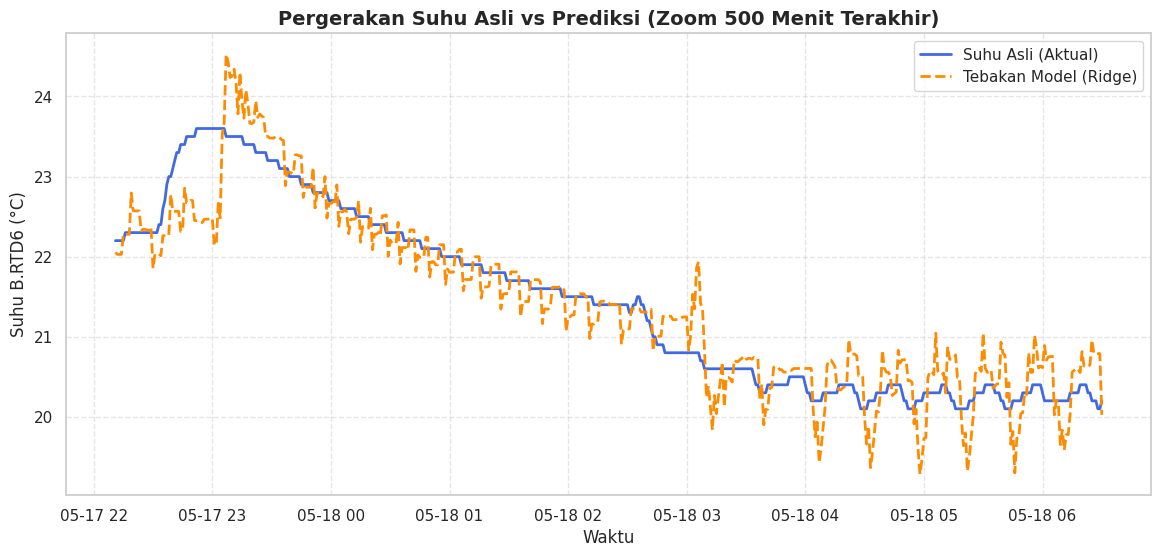

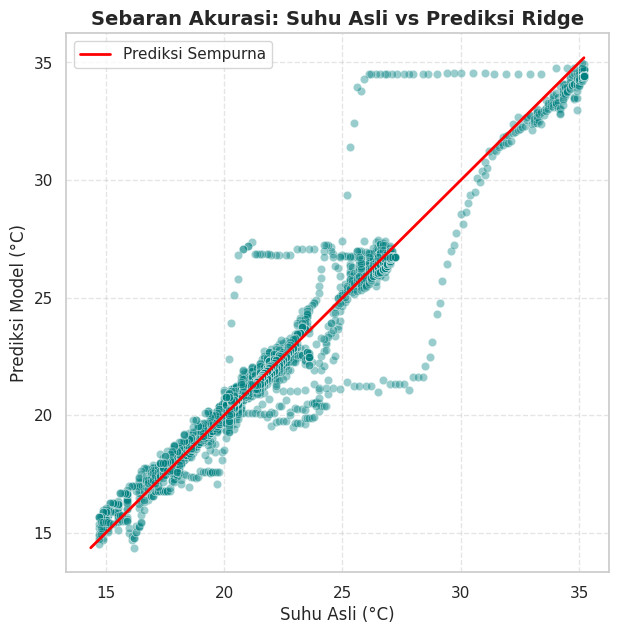

In [22]:
# ==============================================================================
# 🔹 9. VISUALISASI HASIL AKHIR (PEMBUKTIAN SANG JUARA)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Gunakan best_model (Ridge) untuk menebak seluruh data Test
final_predictions = best_model.predict(X_test)

# 2. Susun ke dalam DataFrame agar mudah di-plot
df_result = pd.DataFrame({
    'Waktu': y_test.index,
    'Suhu Asli': y_test.values,
    'Prediksi Ridge': final_predictions
}).set_index('Waktu')

# ------------------------------------------------------------------------------
# GRAFIK 1: Line Plot (Kita zoom di 500 menit terakhir agar bentuknya terlihat jelas)
# ------------------------------------------------------------------------------
plt.figure(figsize=(14, 6))
# Ambil 500 data terakhir agar grafik tidak terlalu padat
zoom_asli = df_result['Suhu Asli'].iloc[-500:]
zoom_pred = df_result['Prediksi Ridge'].iloc[-500:]

plt.plot(zoom_asli.index, zoom_asli, label='Suhu Asli (Aktual)', color='royalblue', linewidth=2)
plt.plot(zoom_pred.index, zoom_pred, label='Tebakan Model (Ridge)', color='darkorange', linestyle='--', linewidth=2)

plt.title('Pergerakan Suhu Asli vs Prediksi (Zoom 500 Menit Terakhir)', fontsize=14, fontweight='bold')
plt.xlabel('Waktu')
plt.ylabel('Suhu B.RTD6 (°C)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ------------------------------------------------------------------------------
# GRAFIK 2: Scatter Plot (Linearitas Prediksi)
# ------------------------------------------------------------------------------
plt.figure(figsize=(7, 7))
sns.scatterplot(x='Suhu Asli', y='Prediksi Ridge', data=df_result, alpha=0.4, color='teal')

# Buat garis merah diagonal (Garis Kesempurnaan)
min_val = min(df_result['Suhu Asli'].min(), df_result['Prediksi Ridge'].min())
max_val = max(df_result['Suhu Asli'].max(), df_result['Prediksi Ridge'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='-', linewidth=2, label='Prediksi Sempurna')

plt.title('Sebaran Akurasi: Suhu Asli vs Prediksi Ridge', fontsize=14, fontweight='bold')
plt.xlabel('Suhu Asli (°C)')
plt.ylabel('Prediksi Model (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

 FINAL MAE      : 0.5855 °C
 FINAL RMSE     : 1.1403 °C
 FINAL ACCURACY : 97.42%


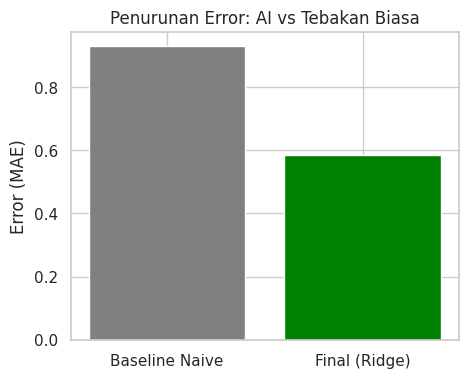

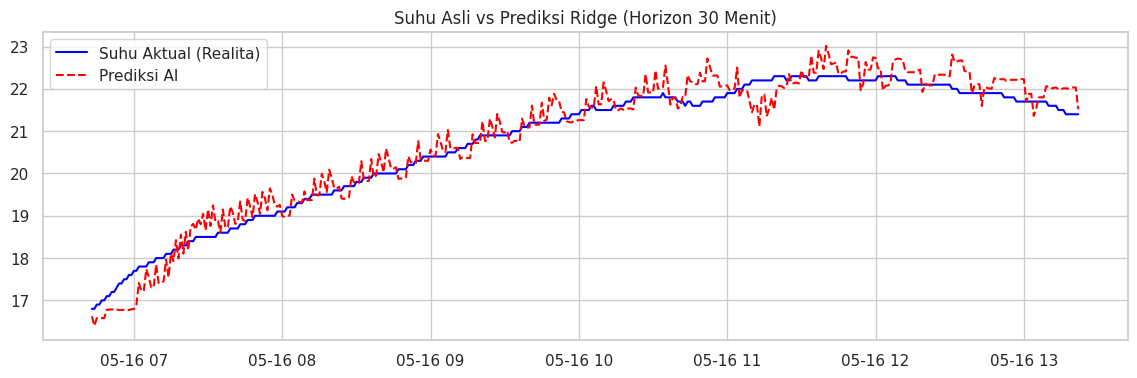

In [23]:
final_pred = best_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_mape = np.mean(np.abs((y_test - final_pred)/(y_test+epsilon)))*100
final_acc = 100 - final_mape

print("="*40)
print(f" FINAL MAE      : {final_mae:.4f} °C")
print(f" FINAL RMSE     : {final_rmse:.4f} °C")
print(f" FINAL ACCURACY : {final_acc:.2f}%")
print("="*40)

# Plot: Baseline vs Final AI
plt.figure(figsize=(5,4))
plt.bar(["Baseline Naive", f"Final ({best_name})"], [baseline_mae, final_mae], color=['gray', 'green'])
plt.title("Penurunan Error: AI vs Tebakan Biasa")
plt.ylabel("Error (MAE)")
plt.show()

# Plot: Garis Waktu Aktual vs Prediksi AI (Ambil 400 menit sampel)
plt.figure(figsize=(14,4))
plt.plot(y_test.index[:400], y_test.values[:400], label="Suhu Aktual (Realita)", color="blue")
plt.plot(y_test.index[:400], final_pred[:400], label="Prediksi AI", color="red", linestyle="--")
plt.title(f"Suhu Asli vs Prediksi {best_name} (Horizon 30 Menit)")
plt.legend()
plt.show()


In [24]:
def smart_hvac_controller(predicted_temp):
    if predicted_temp > 24.5:
        return "Matikan Pemanas (Mencegah Overheating)"
    elif predicted_temp < 20:
        return "Nyalakan Pemanas (Menjaga Kenyamanan)"
    else:
        return "Standby (Suhu Optimal)"

# Contoh jalannya sistem pada menit ke-100 di data testing
idx_sampel = 100
sample_pred = final_pred[idx_sampel]
waktu_kejadian = y_test.index[idx_sampel].strftime('%Y-%m-%d %H:%M')

print("\n🚀 --- SIMULASI SISTEM KONTROL GEDUNG PINTAR --- 🚀")
print(f"Waktu Sistem     : {waktu_kejadian}")
print(f"Prediksi Suhu 30m: {sample_pred:.2f} °C")
print(f"Tindakan Otomatis: {smart_hvac_controller(sample_pred)}")



🚀 --- SIMULASI SISTEM KONTROL GEDUNG PINTAR --- 🚀
Waktu Sistem     : 2024-05-16 08:23
Prediksi Suhu 30m: 19.69 °C
Tindakan Otomatis: Nyalakan Pemanas (Menjaga Kenyamanan)


In [25]:
import pandas as pd

# 1. Logika Pengontrol HVAC
def smart_hvac_controller(predicted_temp):
    if predicted_temp > 24.5:
        return "Matikan Pemanas (Mencegah Overheating)"
    elif predicted_temp < 20:
        return "Nyalakan Pemanas (Menjaga Kenyamanan)"
    else:
        return "Standby (Suhu Optimal)"

# 2. Pilih satu sampel dari data Ujian (Test Set)
idx_sampel = 100

# ==========================================================
# 🔹 VARIABEL WAKTU & SUHU SAAT INI (Waktu T)
# ==========================================================
waktu_sekarang = y_test.index[idx_sampel]
suhu_sekarang = X_test.iloc[idx_sampel]['B.RTD6'] # Suhu asli saat itu

# ==========================================================
# 🔹 VARIABEL WAKTU & SUHU MASA DEPAN (Waktu T + 30 Menit)
# ==========================================================
# Menghitung jam berapa tepatnya 30 menit kemudian
waktu_target = waktu_sekarang + pd.Timedelta(minutes=30)

sample_pred = final_pred[idx_sampel]     # Tebakan AI untuk 30 menit lagi
sample_aktual = y_test.iloc[idx_sampel]  # Fakta sebenarnya 30 menit lagi
selisih = abs(sample_pred - sample_aktual)

# 3. Tampilkan Laporan Simulasi
print("\n🚀 --- SIMULASI SISTEM KONTROL GEDUNG PINTAR --- 🚀")
print("📍 [KONDISI SAAT INI]")
print(f"Waktu Sistem      : {waktu_sekarang.strftime('%Y-%m-%d %H:%M')}")
print(f"Suhu Ruangan Kini : {suhu_sekarang:.2f} °C")

print("\n🔮 [PREDIKSI 30 MENIT KE DEPAN]")
print(f"Target Jam Berapa : {waktu_target.strftime('%Y-%m-%d %H:%M')}")
print("-" * 45)
print(f"Tebakan AI        : {sample_pred:.2f} °C")
print(f"Fakta Sebenarnya  : {sample_aktual:.2f} °C")
print(f"Selisih (Error)   : {selisih:.2f} °C")
print("-" * 45)
print(f"Tindakan Otomatis : {smart_hvac_controller(sample_pred)}")


🚀 --- SIMULASI SISTEM KONTROL GEDUNG PINTAR --- 🚀
📍 [KONDISI SAAT INI]
Waktu Sistem      : 2024-05-16 08:23
Suhu Ruangan Kini : 19.00 °C

🔮 [PREDIKSI 30 MENIT KE DEPAN]
Target Jam Berapa : 2024-05-16 08:53
---------------------------------------------
Tebakan AI        : 19.69 °C
Fakta Sebenarnya  : 19.60 °C
Selisih (Error)   : 0.09 °C
---------------------------------------------
Tindakan Otomatis : Nyalakan Pemanas (Menjaga Kenyamanan)


In [26]:
timestamp_target = '2024-05-16 08:23'
# Mencari data pada timestamp tersebut
try:
    target_data = df.loc[timestamp_target]
    print(f"--- DATA PADA {timestamp_target} ---")
    print(target_data)
except KeyError:
    print(f"Data pada waktu {timestamp_target} tidak ditemukan.")

--- DATA PADA 2024-05-16 08:23 ---
Index
B.RTD6                  19.0
WS1_Solar_radiation    544.2
WS1_Temperature         16.8
pid.SB47.setpoint       40.0
lag_temp_1              19.0
lag_temp_5              18.9
lag_temp_10             18.8
lag_temp_15             18.6
lag_temp_30             18.4
target                  19.6
Name: 2024-05-16 08:23:00+00:00, dtype: float64


In [27]:
timestamp_target = '2024-05-16 08:53'
# Mencari data pada timestamp tersebut
try:
    target_data = df.loc[timestamp_target]
    print(f"--- DATA PADA {timestamp_target} ---")
    print(target_data)
except KeyError:
    print(f"Data pada waktu {timestamp_target} tidak ditemukan.")

--- DATA PADA 2024-05-16 08:53 ---
Index
B.RTD6                  19.6
WS1_Solar_radiation    581.3
WS1_Temperature         16.6
pid.SB47.setpoint       40.0
lag_temp_1              19.6
lag_temp_5              19.5
lag_temp_10             19.5
lag_temp_15             19.3
lag_temp_30             19.0
target                  20.2
Name: 2024-05-16 08:53:00+00:00, dtype: float64


In [28]:
joblib.dump(best_model, "model_rico_final.pkl")
print("\n✅ Model berhasil disimpan sebagai 'model_rico_final.pkl'. Proyek Selesai!")


✅ Model berhasil disimpan sebagai 'model_rico_final.pkl'. Proyek Selesai!


In [29]:
import pandas as pd
import numpy as np
from datetime import datetime

# ==========================================================
# 🔹 1. PERSIAPAN MODEL & LOGIKA (PASTIKAN SUDAH RUN TRAINING)
# ==========================================================
# Menggunakan best_model hasil tuning Ridge yang paling presisi
model_hvac = best_model

def smart_hvac_controller(predicted_temp):
    """Logika Pengambil Keputusan HVAC Otomatis"""
    if predicted_temp > 24.5:
        return "🔴 Matikan Pemanas (Mencegah Overheating)"
    elif predicted_temp < 20:
        return "🔵 Nyalakan Pemanas (Menjaga Kenyamanan)"
    else:
        return "🟢 Standby (Suhu Optimal)"

# ==========================================================
# 🔹 2. INPUT MANUAL (WAKTU & SENSOR)
# ==========================================================
print("=== 🧠 SIMULASI MANUAL SMART BUILDING AI (ENERLOOP) ===")
print("Silakan masukkan data sesuai skenario yang ingin diuji.")
print("-" * 50)

try:
    # --- INPUT WAKTU ---
    waktu_str = input("1. Masukkan Waktu (YYYY-MM-DD HH:MM, contoh 2026-03-01 13:00): ")
    waktu_sekarang = datetime.strptime(waktu_str, '%Y-%m-%d %H:%M')

    # --- INPUT SENSOR UTAMA ---
    temp_now = float(input("2. Suhu Ruangan Saat Ini (°C): "))
    solar    = float(input("3. Intensitas Matahari (W/m²): "))
    temp_out = float(input("4. Suhu Luar Gedung (°C): "))
    setpoint = float(input("5. Setpoint HVAC (Gunakan 40 jika ragu): ") or 40)

    # --- INPUT PEMBANDING ---
    fakta_nanti = float(input("6. Fakta Suhu 30 Menit Lagi (°C) [untuk cek error]: "))

    # ==========================================================
    # 🔹 3. PENGOLAHAN DATA OLEH AI
    # ==========================================================
    # AI butuh 9 kolom input sesuai urutan training:
    # [B.RTD6, WS1_Solar_radiation, WS1_Temperature, pid.SB47.setpoint,
    #  lag_temp_1, lag_temp_5, lag_temp_10, lag_temp_15, lag_temp_30]

    # Untuk demo manual titik tunggal, kita asumsikan kondisi awal stabil
    # (nilai lag = suhu saat ini) agar AI bisa memproses input.
    input_data = pd.DataFrame([[
        temp_now, solar, temp_out, setpoint,
        temp_now, temp_now, temp_now, temp_now, temp_now
    ]], columns=X_train.columns)

    # Prediksi Otomatis
    prediksi_ai = model_hvac.predict(input_data)[0]

    # Hitung Waktu Target & Error
    waktu_target = waktu_sekarang + pd.Timedelta(minutes=30)
    selisih_error = abs(prediksi_ai - fakta_nanti)

    # ==========================================================
    # 🔹 4. LAPORAN HASIL SIMULASI
    # ==========================================================
    print("\n" + "="*55)
    print("🚀 --- LAPORAN PREDIKSI OTOMATIS ENERLOOP AI --- 🚀")
    print(f"Waktu Sistem Input : {waktu_sekarang.strftime('%Y-%m-%d %H:%M')}")
    print(f"Target Jam Prediksi: {waktu_target.strftime('%H:%M')} (30 Menit ke Depan)")
    print("-" * 55)
    print(f"Suhu Ruangan Kini  : {temp_now:.2f} °C")
    print(f"TEBAKAN AI (30m)   : {prediksi_ai:.2f} °C 👈 (Hasil Otomatis)")
    print(f"Fakta Sebenarnya   : {fakta_nanti:.2f} °C")
    print(f"Akurasi Error      : {selisih_error:.4f} °C")
    print("-" * 55)
    print(f"TINDAKAN OTOMATIS  : {smart_hvac_controller(prediksi_ai)}")
    print("="*55)

except ValueError:
    print("\n❌ Error: Format salah! Pastikan waktu (YYYY-MM-DD HH:MM) dan angka suhu benar.")
except Exception as e:
    print(f"\n❌ Terjadi Kesalahan: {e}")

=== 🧠 SIMULASI MANUAL SMART BUILDING AI (ENERLOOP) ===
Silakan masukkan data sesuai skenario yang ingin diuji.
--------------------------------------------------
1. Masukkan Waktu (YYYY-MM-DD HH:MM, contoh 2026-03-01 13:00): 21

❌ Error: Format salah! Pastikan waktu (YYYY-MM-DD HH:MM) dan angka suhu benar.


In [31]:
# Asumsi 'df' adalah dataframe yang sudah berisi fitur lag
df.to_csv('data_B.RTD6_Clean.csv', index=True)